In [27]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

In [5]:
X, Y = make_classification(n_features = 5, n_redundant = 0, n_informative = 5, n_clusters_per_class = 1)

In [8]:
df = pd.DataFrame(X, columns = ["Col1", "Col2", "Col3", "Col4", "Col5"])
df["Target"] = Y

In [9]:
df.head()

,Col1,Col2,Col3,Col4,Col5,Target
0,-0.861203,-1.731014,-2.611991,-0.687794,1.340980,0
1,-0.423504,-0.809801,-3.057506,0.143886,0.041439,0
2,1.125681,0.683205,1.042463,-0.161656,-2.326909,1
3,0.781120,2.051156,-0.237180,0.867515,0.158541,1
4,1.318720,-0.111666,2.089856,-1.054714,-3.252619,1


In [10]:
len(df)

100

# Splitting the data into training & test

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [17]:
len(X_train)

80

In [18]:
len(X_test)

20

# Feature Scaling


In [20]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [21]:
X_train

array([[ 1.48821213, -1.30382902,  0.16085281,  0.98300647,  0.81665036],
       [-2.15078068,  0.61947115, -0.20181485,  1.40387108,  0.61372843],
       [-0.55404056, -0.76782505, -1.57373641, -1.25007625,  0.90968131],
       [ 0.72262394,  0.14490332,  1.21222831, -1.84993176, -2.02624824],
       [ 0.35238276, -0.75821194, -0.90932024,  0.14859479,  0.40166549],
       [ 1.85273641,  1.10305496,  0.08049368,  1.94228271, -0.26731572],
       [ 0.22675997, -0.25348593, -0.2750967 ,  0.07832891,  0.99278353],
       [-0.37706191,  0.73645033,  0.33492071, -0.62043537, -0.39320585],
       [-0.68358682,  0.96090192,  0.50853527,  0.45097659, -0.31130532],
       [ 0.48989543, -0.19422884, -0.38848729,  0.21417335,  0.82027381],
       [ 1.05555965, -0.07201228, -0.48638615,  0.70944052,  0.31515036],
       [ 1.25184859,  0.0065285 ,  0.53130856,  0.74062058,  1.25337276],
       [-1.00213261,  0.35243506,  0.48933563,  0.47879422, -0.41795588],
       [-1.46330154, -0.66411492, -2.7

In [22]:
X_test

array([[ 0.21125507, -0.09129457, -0.18648625, -0.15295691,  1.2849299 ],
       [ 0.19433334, -0.03151867,  0.93709444, -2.22280349, -1.48714104],
       [ 0.85501632, -1.70529203, -0.82448322,  0.08153666,  0.66150229],
       [-1.12703657, -1.04348785,  1.11392688, -1.85059042, -1.74393589],
       [ 1.28596629, -1.38521897, -0.03434951,  0.54001654,  0.97106957],
       [-0.32761591, -0.17986619, -1.02922551, -0.73589315,  0.96565673],
       [-0.70401734, -0.90787172, -1.48012355, -1.00380786,  0.80074459],
       [ 0.98371866, -0.12959185, -0.43933707,  0.53937405,  0.48728471],
       [-0.56733067,  0.97969982,  0.05967414,  1.1525634 ,  0.78984654],
       [-2.83030923,  0.76281155,  0.44772728,  1.2491303 ,  0.73573912],
       [ 0.4121256 ,  0.50589558,  0.15873085, -1.59185523, -0.86588678],
       [ 0.99116216,  2.09313194,  0.37413187,  0.90084143, -0.67503822],
       [-1.46831414,  1.04110213, -0.19856804,  1.18699506, -0.05166279],
       [-0.94489984, -1.16079231, -1.6

# Bag Classifier

In [24]:
bag = BaggingClassifier(max_features = 2)

In [25]:
bag.fit(X_train,Y_train)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,2
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


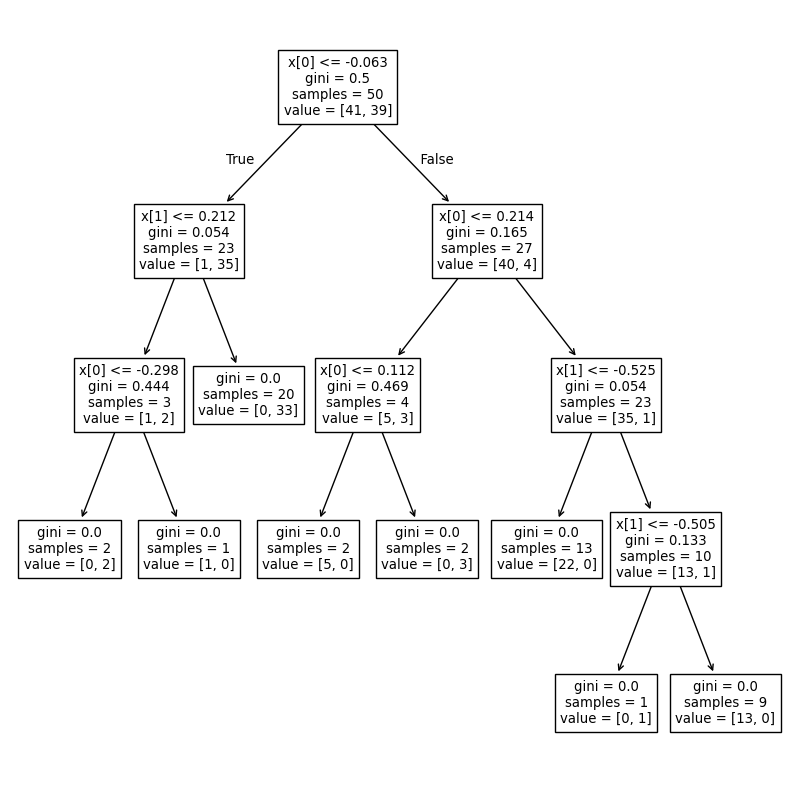

In [28]:
plt.figure(figsize=(10,10))
### Phelay model ka decision tree dekhao *agar 10 banaya hain toh phelay ka decision tree
plot_tree(bag.estimators_[0])
plt.show()

### Where the values come from?

#### har split ke baad Gini impurity calculate karta hai. Jo split classes ko best separate kare, tree us threshold ko choose karta hai.

# Random Forest Classifier

In [29]:
bag1 = RandomForestClassifier(max_features = 2)

In [30]:
bag1.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


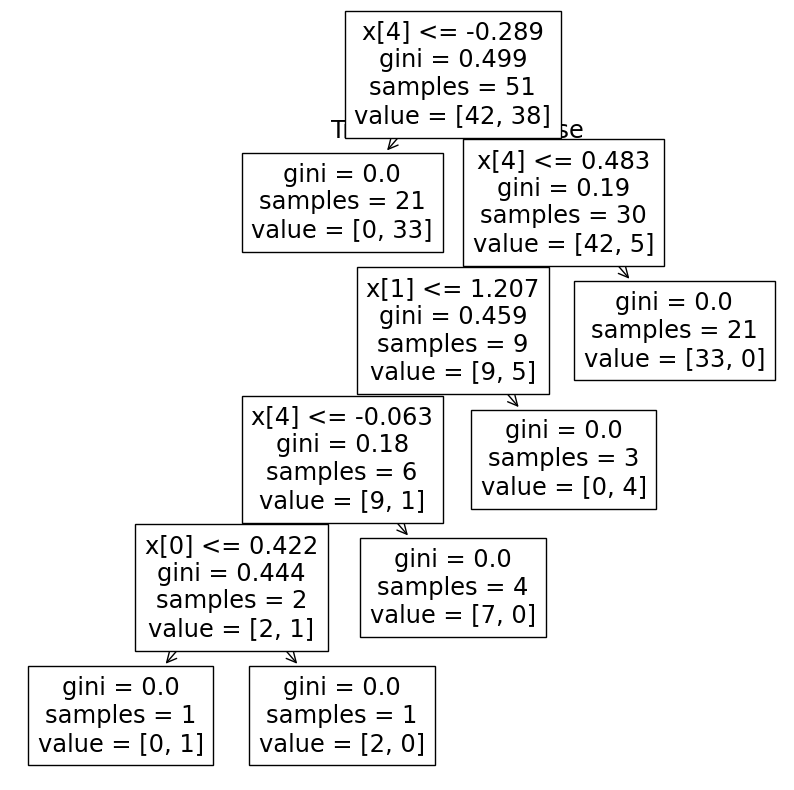

In [31]:
plt.figure(figsize=(10,10))
### Phelay model ka decision tree dekhao *agar 10 banaya hain toh phelay ka decision tree
plot_tree(bag1.estimators_[0])
plt.show()